In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata

from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results


import tensorflow as tf
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=8, usetex=False)

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


KeyboardInterrupt: 

In [2]:
import pandas as pd
higgs = pd.read_csv("C:/Users/havef/OneDrive/Desktop/Astro/higgs.csv")

higgs

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,4.505083,b
249996,349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,2.497259,b
249997,349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,...,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992,0.018636,s
249998,349998,94.951,19.362,68.812,13.504,-999.00,-999.000,-999.000,3.365,13.504,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.681611,b


#### converting the data to an array of floats

In [25]:
data_to_float = higgs.to_numpy()

data = np.asfarray(data_to_float[:,0], dtype = float)
for i in range (np.size(data_to_float[0,:] )-1):
    
    if (type(data_to_float[0][i]) == 'str'):
        data = np.column_stack((data , data_to_float[:,i]))
    else:
        data = np.column_stack((data , np.asfarray(data_to_float[:,i], dtype = float)))

labels = data_to_float[:,32]
names = higgs.columns

In [20]:

np.where(labels != 's')
size_s = np.size(labels[np.where(labels == 's')])
size_b = np.size(labels[np.where(labels == 'b')])
if(size_s + size_b == np.size(labels)):
    print("there are just s and b as labels")
else :
    print("there are other labels then s and b")

there are just s and b as labels


In [21]:
#converting labels 
index = np.zeros((np.size(labels)))
for i in range (np.size(labels)):
    if(labels[i] == 's'):
        index[i] = 1.
    else:
        index[i] = 0.
index = index.reshape(-1,1)

In [22]:
#cleaning data function used in gamma ray burst analysis

def clean_data(name1 , name2 , data):
    #tovo dove si trovano name1 e name2 nell'array data (a quale colonna corrispondono)
    A = np.where(names == name1)[0][0]
    B = np.where(names == name2)[0][0]
    
    #pulisco name1
    name1_raw = data[A][data[A] != '-999']
    name2_raw = data[B][data[A] != '-999']
    
    #converto ad array
    float_name1 = np.asfarray(name1_raw ,dtype = float)
    float_name2 = np.asfarray(name2_raw ,dtype = float)
    
    #pulisco name2
    new_name2 = float_name2[float_name2 != -999]
    new_name1 = float_name1[float_name2 != -999]
    
    return [new_name1 , new_name2]

In [13]:
data[:,0]

array([100000., 100001., 100002., ..., 349997., 349998., 349999.])

In [44]:
names

Index(['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt',
       'Weight', 'Label'],
      dtype='object')

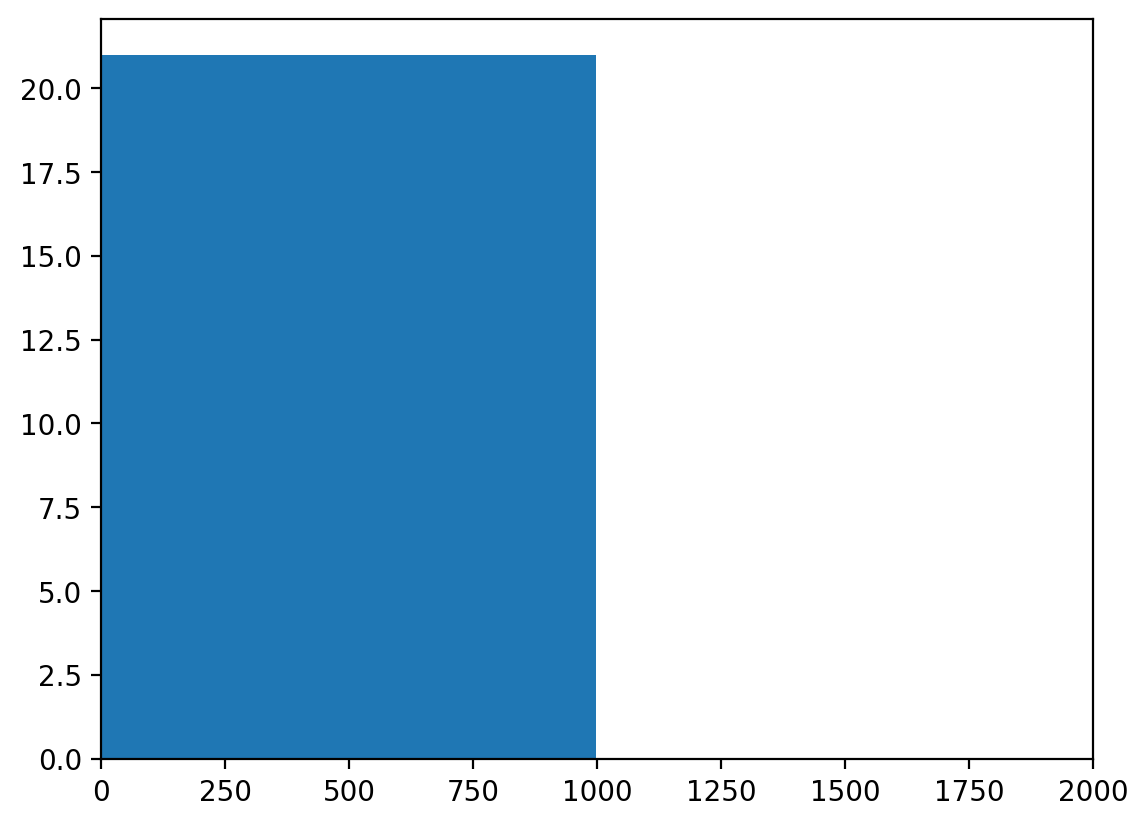

In [43]:
DER_mass_MMC = data[:,1]
DER_pt_h = data[:,4]
clean_data('DER_mass_MMC' , 'DER_pt_h' , data)
DER_mass_MMC = clean_data('DER_mass_MMC' , 'DER_pt_h' , data)[0]
DER_pt_h = clean_data('DER_mass_MMC' , 'DER_pt_h' , data)[1]
#plt.scatter(DER_mass_MMC ,DER_pt_h , s=4)
plt.hist(DER_pt_h, bins = 100)
plt.xlim(-0.1 , 2000)
plt.show()


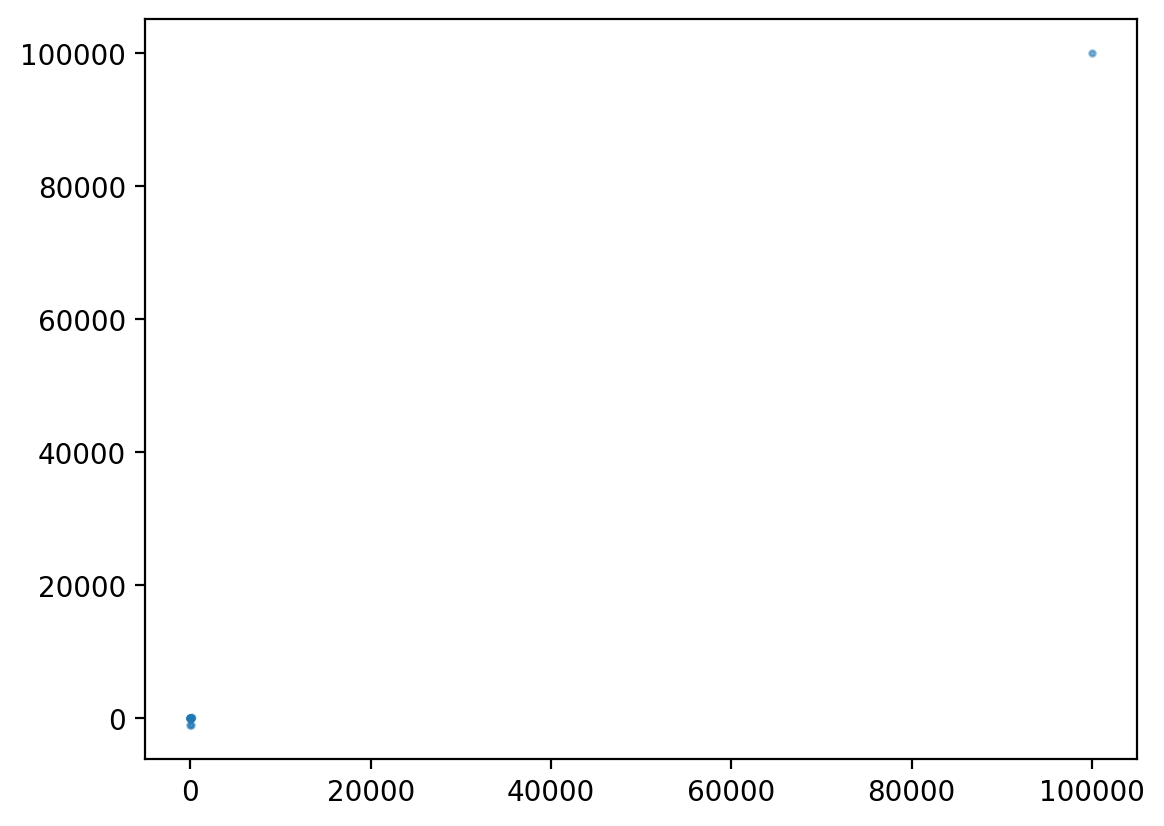

In [48]:
PRI_tau_pt = data[:,np.where(names=='PRI_tau_pt')[0]]
PRI_tau_phi = data[:,np.where(names=='PRI_tau_phi')[0]]

clean_data('PRI_tau_pt' , 'PRI_tau_phi' , data)
PRI_tau_pt = clean_data('PRI_tau_pt' , 'PRI_tau_phi' , data)[0]
PRI_tau_phi = clean_data('PRI_tau_pt' , 'PRI_tau_phi' , data)[1]

plt.scatter(PRI_tau_phi, PRI_tau_pt, s=4 , alpha = 0.3)
plt.show()